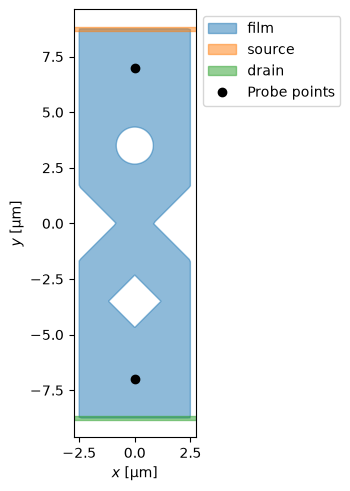

In [42]:
import numpy as np
import tdgl
from tdgl.geometry import box, circle
from tdgl.sources import LinearRamp, ConstantField
import h5py
from tdgl.visualization.animate import create_animation

length_units = "um"
xi, london_lambda, d = 0.25, 2, 0.1
layer = tdgl.Layer(coherence_length=xi, london_lambda=london_lambda,
                   thickness=d, gamma=1)

total_width, total_length = 5, 17.5
link_width = total_width / 3

right_notch = (tdgl.Polygon(points=box(total_width))
               .rotate(45)
               .translate(dx=(np.sqrt(2) * total_width + link_width) / 2))
left_notch = right_notch.scale(xfact=-1)

film = (tdgl.Polygon("film", points=box(total_width, total_length))
        .difference(right_notch, left_notch)
        .resample(401)
        .buffer(0))

round_hole = tdgl.Polygon("round_hole", points=circle(link_width / 2)).translate(dy=total_length / 5)
square_hole = tdgl.Polygon("square_hole", points=box(link_width)).rotate(45).translate(dy=-total_length / 5)

source = tdgl.Polygon("source", points=box(1.1 * total_width, total_length / 100)).translate(dy=total_length / 2)
drain = source.scale(yfact=-1).set_name("drain")

probe_points = [(0, total_length / 2.5), (0, -total_length / 2.5)]

device = tdgl.Device("weak_link", layer=layer, film=film,
                     holes=[round_hole, square_hole],
                     terminals=[source, drain],
                     probe_points=probe_points,
                     length_units=length_units)
fig, ax = device.draw()

In [29]:
device.make_mesh(max_edge_length=xi / 2, smooth=100) # min_points is also a parameter to use

Constructing Voronoi polygons:   0%|          | 0/17236 [00:00<?, ?it/s]Malformed Voronoi cell surrounding boundary site 4. Try changing the number of boundary mesh sites using Polygon.resample() or Polygon.buffer(eps) where eps is 0 or a small positive float.
Malformed Voronoi cell surrounding boundary site 8. Try changing the number of boundary mesh sites using Polygon.resample() or Polygon.buffer(eps) where eps is 0 or a small positive float.
Malformed Voronoi cell surrounding boundary site 10. Try changing the number of boundary mesh sites using Polygon.resample() or Polygon.buffer(eps) where eps is 0 or a small positive float.
Malformed Voronoi cell surrounding boundary site 22. Try changing the number of boundary mesh sites using Polygon.resample() or Polygon.buffer(eps) where eps is 0 or a small positive float.
Malformed Voronoi cell surrounding boundary site 30. Try changing the number of boundary mesh sites using Polygon.resample() or Polygon.buffer(eps) where eps is 0 or a sm

num_sites,17236
num_elements,33605
min_edge_length,3.409e-02
max_edge_length,1.215e-01
mean_edge_length,7.298e-02
min_area,8.385e-04
max_area,8.962e-03
mean_area,4.469e-03
coherence_length,2.500e-01
length_units,um


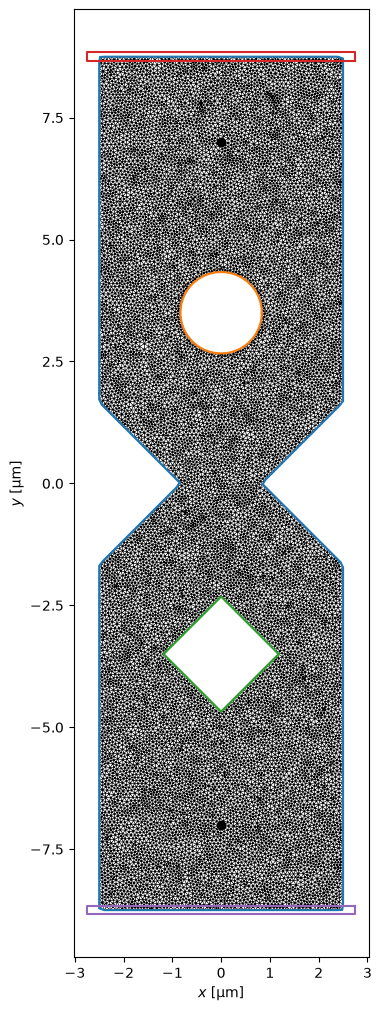

In [30]:
display(device.mesh_stats())
fig, ax = device.plot(mesh=True, legend=False, figsize=(5, 10))

In [31]:
options = tdgl.SolverOptions(
    skip_time=100,
    solve_time=150,
    output_file="weak-link.h5",
    field_units="mT",
    current_units="uA",
    save_every=100,
)

applied_vector_potential = (
    LinearRamp(tmin=0, tmax=100)
    * ConstantField(0.4, field_units=options.field_units,
                    length_units=device.length_units)
)
    
solution = tdgl.solve(
    device,
    options,
    applied_vector_potential=applied_vector_potential,
    terminal_currents=dict(source=12, drain=-12),
)

Simulating: 100%|█████████▉| 150/150 [12:01<00:00,  4.81s/tau ]


In [38]:
# with h5py.File("weak-link.h5", "r") as f:
#     f.visit(print)

with tdgl.non_gui_backend():
    with h5py.File(solution.path, "r") as h5file:
        anim = create_animation(h5file, quantities=("order_parameter", "phase"),
                                fps=20, figure_kwargs=dict(figsize=(5, 4)))
HTML(anim.to_html5_video())

TypeError: an integer is required

NameError: name 'HTML' is not defined

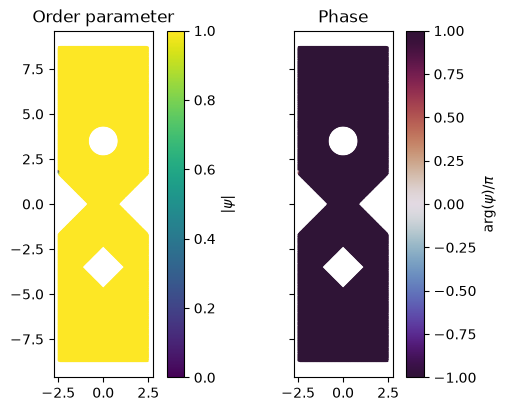

In [43]:
with h5py.File(solution.path, "r") as h5file:
    n = len(h5file["data"].keys())
    anim = create_animation(h5file, quantities=("order_parameter", "phase"),
                            fps=20, min_frame=0, max_frame=n - 1,
                            figure_kwargs=dict(figsize=(5, 4)))
    video = HTML(anim.to_html5_video())
video